In [1]:
import os
import dill
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [5]:
def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(5):

        corr_dict[react_day] = {}
        # sess = u.load_single_day(mouse, react_day)

        for tt_corr_day in range(react_day+1,6):
        
            corr_dict[react_day][tt_corr_day] ={}
            
            days = [react_day, tt_corr_day]
            
            if react_day == tt_corr_day:
                
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    hse_tt_corr = hse_react
                    hse_tt_corr = u.load_single_day(mouse, tt_corr_day, trial_mat_keys=['F_dff_nostop',], verbose=False)
                
                    
                common_roi_mapping = np.array([np.arange(hse_react.spks.shape[0]) for _ in range(2)])
                
            else:
                common_roi_mapping = u.common_rois_adjust(mouse, days)
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    sess = u.load_single_day(mouse, react_day, trial_mat_keys=['F_dff_nostop'], timeseries_keys=['F_dff_nostop'], verbose=False)
               
                    
                hse_tt_corr = u.load_single_day(mouse, tt_corr_day, trial_mat_keys=['F_dff_nostop',], timeseries_keys=['F_dff_nostop'],verbose=False)
                
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                   
                # reactivation mask
                if key == 'fam':
                    trial_mask = hse_tt_corr.trial_info["LR"]!=hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr!=hse_react.novel_arm
                    react_trial_mask = hse_react.trial_info["LR"]!= hse_react.novel_arm
                else:
                    trial_mask = hse_tt_corr.trial_info["LR"]==hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr==hse_react.novel_arm
                    react_trial_mask = hse_react.trial_info["LR"]==hse_react.novel_arm
                

                ts_mask = lr_mask * (hse_react.post_reward_bool>0)
              
                # ts_mask = (hse_react.post_reward_bool>0) * (hse_react.block_number==5)
               
                if ts_mask.sum()<30:
                    corr_dict[react_day][tt_corr_day][key]['tt_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['hse_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['across_day_corr'] =[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['cell_argmax'] = [np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['react_cell_argmax'] = [np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['react_corr'] = [np.nan,]
                    continue
               

                hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                                        hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask], axis=-1)    

                # trial_mat = hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                trial_mat = hse_tt_corr.trial_matrices['F_dff_nostop'][trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                cell_argmax = np.nanargmax(np.nanmean(trial_mat,axis=0),axis=0)
                trial_mat[np.isnan(trial_mat)]=0
                corr_mat = np.zeros([trial_mat.shape[0], trial_mat.shape[0], trial_mat.shape[-1]])

               
                for cell in range(corr_mat.shape[-1]):
                    _mat = np.corrcoef(trial_mat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                react_trial_mat = sess.trial_matrices['F_dff_nostop'][react_trial_mask,:,:][:,:,common_roi_mapping[0,:]]
                react_trial_mat[np.isnan(react_trial_mat)]=0
                react_corr_mat = np.zeros((react_trial_mat.shape[0], react_trial_mat.shape[0], react_trial_mat.shape[-1]))
                for cell in range(react_corr_mat.shape[-1]):
                    _mat = np.corrcoef(react_trial_mat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    react_corr_mat[:, :,cell] = _mat

                corr_dict[react_day][tt_corr_day][key]['tt_corr']=np.array([np.nanmean(np.nanmean(corr_mat,axis=0),axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['react_corr']=np.array([np.nanmean(np.nanmean(react_corr_mat, axis=0), axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([hse_r]).flatten()
                corr_dict[react_day][tt_corr_day][key]['cell_argmax'] = np.array([cell_argmax]).flatten()


                react_trial_mat = sess.trial_matrices['F_dff_nostop'][react_trial_mask,:,:][:,:,common_roi_mapping[0,:]]
                react_trial_mat_mean = np.nanmean(react_trial_mat,axis=0)
                corr_dict[react_day][tt_corr_day][key]['react_cell_argmax'] = np.nanargmax(react_trial_mat_mean,axis=0)

                # trial_mat_mean = np.nanmean(hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]], axis=0)
                trial_mat_mean = np.nanmean(hse_tt_corr.trial_matrices['F_dff_nostop'][trial_mask,:,:][:,:,common_roi_mapping[1,:]], axis=0)
                
                react_trial_mat_mean[np.isnan(react_trial_mat_mean)]=0
                trial_mat_mean[np.isnan(trial_mat_mean)]=0
                across_day_corr = np.zeros([trial_mat_mean.shape[-1],])
                for cell in range(trial_mat_mean.shape[-1]):
                    _r,_ = sp.stats.pearsonr(react_trial_mat_mean[:,cell], trial_mat_mean[:,cell])
                    across_day_corr[cell] = _r

                corr_dict[react_day][tt_corr_day][key]['across_day_corr'] = np.array(across_day_corr).flatten()


                
    return corr_dict


In [6]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        corr_dict = predict_future_tt_stability(mouse)
        for i in range(5):
            for j in range(i+1,6):
                for ttype in ('fam', 'nov'):
                
                    hse_corr = corr_dict[i][j][ttype]['hse_corr']
                    tt_corr =  corr_dict[i][j][ttype]['tt_corr']
                    across_day_corr = corr_dict[i][j][ttype]['across_day_corr']
                    cell_argmax = corr_dict[i][j][ttype]['cell_argmax']
                    react_argmax = corr_dict[i][j][ttype]['react_cell_argmax']
                    react_corr = corr_dict[i][j][ttype]['react_corr']
                    # print(hse_corr.shape)
                    
                    nanmask = np.isnan(np.array(hse_corr).flatten()*np.array(tt_corr).flatten())
                    nanmask = np.array([nanmask,]).ravel()
                    if nanmask.shape[0]==1:
                        continue
                    # print(hse_corr)
                    hse_corr[nanmask] = 0
                

                    for hse, tt, ad,amax,r_amax, r_corr in zip(hse_corr, tt_corr, across_day_corr, cell_argmax, react_argmax, react_corr):
                        rows.append({'condition':cond,
                                    'mouse':mouse,
                                    'ttype': ttype,
                                    'hse_day':i,
                                    'tt_day':j,
                                    'hse_corr':hse,
                                    'tt_corr':tt,
                                    'across_day_corr': ad,
                                    'cell_argmax': amax,
                                    'react_cell_argmax': r_amax,
                                    'react_corr': r_corr})
df = pd.DataFrame(rows)


4467331.1
4467331.1


/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

4467331.2
4467331.2


/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


[3, 4]
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel


...

/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

Cre7
Cre7


/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

Cre9
Cre9


/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_274373/1890368594.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

In [7]:
df.to_pickle('/home/mplitt/shuffle_pkls/hse_corr_results_dff.pkl')

In [42]:
with open('/home/mplitt/shuffle_pkls/hse_corr_results_dff.pkl', 'rb') as file:
    df = pickle.load(file)

In [43]:
cre_mask = df['condition']=='cre'
nonzero_mask = df['hse_corr']>0

df['hse_zero_mask'] = 1.*(df['hse_corr']==0)
# df['tt_corr_diff'] = df['tt_corr']-df['react_corr']

In [44]:
# proportion that are inactive 

# hse corr of proportion that are active

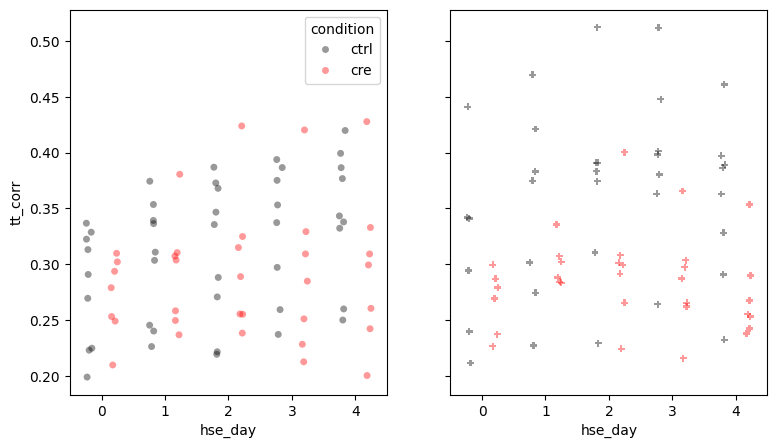

In [34]:
# tt_corr for inactive 
tmp_df = df.loc[df['hse_zero_mask']==0].groupby(['condition', 'hse_day', 'mouse', 'ttype']).mean().reset_index()
fig, ax = plt.subplots(1,2,figsize=[9,5], sharey=True)
_ = sns.stripplot(data=tmp_df.loc[tmp_df['ttype']=='fam'],
                  x='hse_day',
                  y='tt_corr',
                  hue='condition',
                  hue_order=['ctrl', 'cre'],
                  palette=['black', 'red'],
                  ax=ax[0], alpha=.4, dodge=True,)

_ = sns.stripplot(data=tmp_df.loc[tmp_df['ttype']=='nov'],
                  x='hse_day',
                  y='tt_corr',
                  hue='condition',
                  hue_order=['ctrl', 'cre'],
                  palette=['black', 'red'],
                  ax=ax[1], alpha=.4, dodge=True,marker='P',
                  legend=False)





<Axes: xlabel='hse_corr', ylabel='Proportion'>

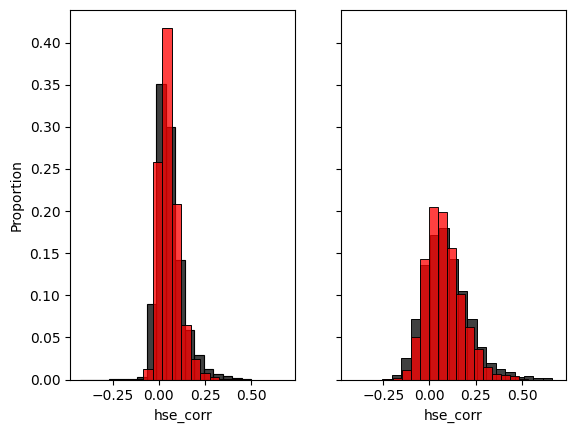

In [35]:
fig,ax = plt.subplots(1,2, sharex=True, sharey=True)
sns.histplot(data=df.loc[(df['ttype']=='fam')*(df['hse_zero_mask']==0)*(df['condition']=='ctrl')],
             x='hse_corr',
             color='black', ax=ax[0], stat='proportion', binwidth=.05)


sns.histplot(data=df.loc[(df['ttype']=='nov')*(df['hse_zero_mask']==0)*(df['condition']=='ctrl')],
             x='hse_corr',
             color='black', ax=ax[1], stat='proportion', binwidth=.05)


sns.histplot(data=df.loc[(df['ttype']=='fam')*(df['hse_zero_mask']==0)*(df['condition']=='cre')],
             x='hse_corr',
             color='red', ax=ax[0], stat='proportion', binwidth=.05)


sns.histplot(data=df.loc[(df['ttype']=='nov')*(df['hse_zero_mask']==0)*(df['condition']=='cre')],
             x='hse_corr',
             color='red', ax=ax[1], stat='proportion', binwidth=.05)


In [39]:
df['hse_corr_z'] = np.arctanh(df['hse_corr'])
df['tt_corr_z'] = np.arctanh(df['tt_corr'])
df['across_day_corr_z'] = np.arctanh(df['across_day_corr'])
df_pos = df.loc[nonzero_mask].groupby(['condition','hse_day', 'tt_day', 'ttype', 'mouse']).mean().reset_index()
df_neg = df.loc[~nonzero_mask].groupby(['condition','hse_day', 'tt_day', 'ttype', 'mouse']).mean().reset_index()
df_pos['positive']= True
df_neg['positive']= False

In [50]:
df_pos['tt_corr_diff'] = df_pos['tt_corr']-df_neg['tt_corr']

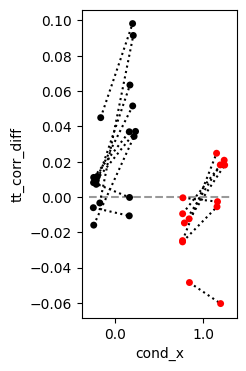

In [51]:
tmp_df = df_pos.groupby(['condition', 'mouse', 'ttype']).mean().reset_index()
tmp_df['cond_x'] = 1.*(tmp_df['condition']=='cre')

fig, ax = plt.subplots(figsize=[2,4])
sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='ctrl'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['black', 'black'],
              legend=False,
              ax=ax)

sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='cre'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['red', 'red'],
              legend=False,
              ax=ax)
for d in [0,2]:
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
ax.hlines(0,-.3, 1.3, linestyle='--', color='black', alpha=.4)


In [ ]:
sess = u.load_single_day(ctrl_mice[0],0)
rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

df['cell_argmax_rz_centered']=np.nan
df['react_cell_argmax_rz_centered']=np.nan
for cond, mice in zip(('ctrl', 'cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
                        
        if cond=='ctrl':
            novel_arm = stx.ymaze_sess_deets.CTRL_sessions[mouse][day]['novel_arm']
        else:
            novel_arm = stx.ymaze_sess_deets.KO_sessions[mouse][day]['novel_arm']

        if novel_arm == 1: 
            rz_nov = rz_late
            rz_fam = rz_early
        else: 
            rz_nov = rz_early
            rz_fam = rz_late

        for ttype in ('nov', 'fam'):
            if ttype == 'nov':
                rz = rz_nov
            else:
                rz = rz_fam
            mask = (df['mouse']==mouse) * (df['ttype']==ttype)
            df.loc[mask, 'cell_argmax_rz_centered'] = df['cell_argmax'] - rz[0]
            df.loc[mask, 'react_cell_argmax_rz_centered'] = df['react_cell_argmax'] - rz[0]


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


(-10.0, 3.0)

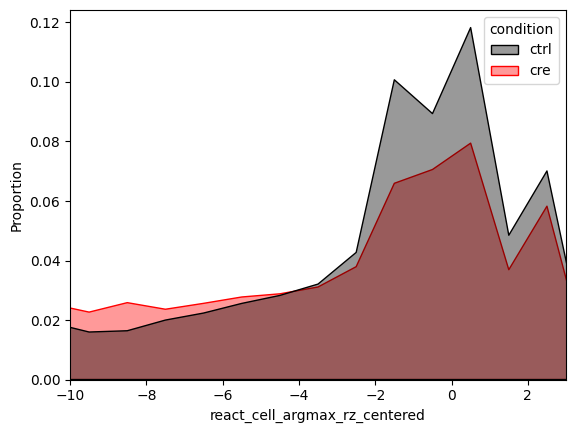

In [18]:
fig, ax = plt.subplots()
sns.histplot(data=df.loc[nonzero_mask*df['ttype']=='fam'],
             x='react_cell_argmax_rz_centered',
             hue='condition',
             hue_order=['ctrl', 'cre'],
             palette=['black', 'red'], 
             element='poly',
             stat='proportion', common_norm=False, fill=True, alpha=.4, binwidth=1, ax=ax)

ax.set_xlim([-10,3])


(-10.0, 3.0)

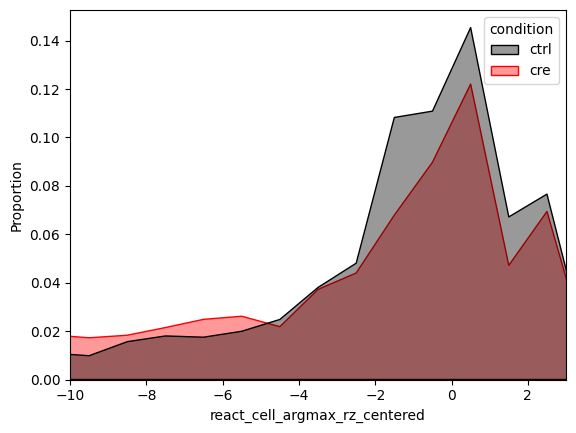

In [19]:
fig, ax = plt.subplots()
sns.histplot(data=df.loc[nonzero_mask*df['ttype']=='nov'],
             x='react_cell_argmax_rz_centered',
             hue='condition',
             hue_order=['ctrl', 'cre'],
             palette=['black', 'red'], 
             element='poly',
             stat='proportion', common_norm=False, fill=True, alpha=.4, binwidth=1, ax=ax)

ax.set_xlim([-10,3])


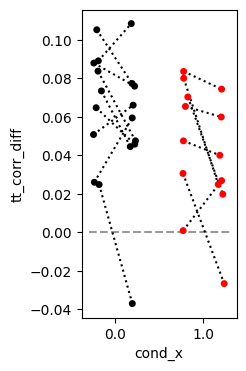

In [27]:
tmp_df = df.copy()
# mask = (tmp_df['react_cell_argmax_rz_centered']<=-5)+(tmp_df['react_cell_argmax_rz_centered']>3)
mask = (tmp_df['cell_argmax_rz_centered']>=-5)+(tmp_df['cell_argmax_rz_centered']<3)

tmp_df_pos = tmp_df.loc[mask*nonzero_mask].groupby(['condition', 'mouse', 'ttype','hse_day', 'tt_day']).mean().reset_index()
tmp_df_neg = tmp_df.loc[mask*(~nonzero_mask)].groupby(['condition', 'mouse', 'ttype', 'hse_day', 'tt_day']).mean().reset_index()
# tmp_df_pos['tt_corr_diff'] = tmp_df_pos['tt_corr_z']-tmp_df_neg['tt_corr_z']

tmp_df_neg= tmp_df_neg.groupby(['condition', 'mouse', 'ttype']).mean().reset_index()
tmp_df_neg['cond_x'] = 1.*(tmp_df_neg['condition']=='cre')



fig, ax = plt.subplots(figsize=[2,4])
sns.stripplot(data=tmp_df_neg.loc[tmp_df_neg['condition']=='ctrl'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['black', 'black'],
              legend=False,
              ax=ax)

sns.stripplot(data=tmp_df_neg.loc[tmp_df_neg['condition']=='cre'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['red', 'red'],
              legend=False,
              ax=ax)
for d in [0,2]:
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
ax.hlines(0,-.3, 1.3, linestyle='--', color='black', alpha=.4)


In [ ]:
# for each mouse
rows = []
for cond, mice in zip(('ctrl', 'cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(5):                      
            
            if cond=='ctrl':
                novel_arm = stx.ymaze_sess_deets.CTRL_sessions[mouse][0]['novel_arm']
            else:
                novel_arm = stx.ymaze_sess_deets.KO_sessions[mouse][0]['novel_arm']

            if novel_arm == 1: 
                rz_nov = rz_late
                rz_fam = rz_early
            else: 
                rz_nov = rz_early
                rz_fam = rz_late

            for ttype in ('nov', 'fam'):
                if ttype == 'nov':
                    rz = rz_nov
                else:
                    rz = rz_fam


                mask = (df['mouse']==mouse) * (df['ttype']==ttype) * (df['hse_day']==day)
                # positively correlated
                tmp_df = df.loc[nonzero_mask*mask]
                prop_posreward = (1.*((tmp_df['cell_argmax_rz_centered']<=1) * (tmp_df['cell_argmax_rz_centered']>=-5))).mean()

                # rows.append({'condition': cond,
                #              'mouse': mouse, 
                #              'hse_day': day,
                #              'ttype': ttype,
                #             #  'positive': True,
                #              'prop_reward': prop_reward})

                tmp_df = df.loc[~nonzero_mask*mask]
                prop_negreward = (1.*((tmp_df['cell_argmax_rz_centered']<=1) * (tmp_df['cell_argmax_rz_centered']>=-5))).mean()

                rows.append({'condition': cond,
                             'mouse': mouse, 
                             'hse_day': day,
                             'ttype': ttype,
                             'prop_reward': prop_posreward,
                             'prop_negreward': prop_negreward,
                             'prop_reward_diff': prop_posreward-prop_negreward})


reward_frac_df = pd.DataFrame(rows)

<Axes: xlabel='hse_day', ylabel='prop_reward'>

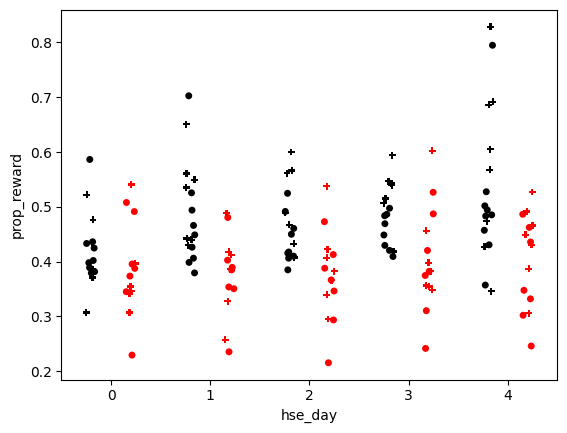

In [21]:
sns.stripplot(data = reward_frac_df.loc[(reward_frac_df['ttype']=='fam')],
              x='hse_day',
              y='prop_reward',
              hue='condition',
              hue_order=['ctrl','cre'],
              palette=['black','red'], legend=False,
              dodge=True)


sns.stripplot(data = reward_frac_df.loc[(reward_frac_df['ttype']=='nov')],
              x='hse_day',
              y='prop_reward',
              hue='condition',
              hue_order=['ctrl','cre'],
              palette=['black','red'],
              marker='P', legend=False,
              dodge=True)

In [23]:
aov = pg.mixed_anova(data = reward_frac_df.loc[(reward_frac_df['ttype']=='fam') ], 
                     subject='mouse',
                     within='hse_day',
                     between='condition',
                     dv='prop_reward')
print(aov)

aov = pg.mixed_anova(data = reward_frac_df.loc[(reward_frac_df['ttype']=='nov') ], 
                     subject='mouse',
                     within='hse_day',
                     between='condition',
                     dv='prop_reward')
print(aov)

        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  0.082623    1   13  0.082623  4.805371  0.047175  0.269883   
1      hse_day  0.008895    4   52  0.002224  1.573881  0.195096  0.107993   
2  Interaction  0.014309    4   52  0.003577  2.531731  0.051284  0.163004   

        eps  
0       NaN  
1  0.703618  
2       NaN  
        Source        SS  DF1  DF2        MS         F     p-unc       np2  \
0    condition  0.130268    1    8  0.130268  5.122059  0.053455  0.390340   
1      hse_day  0.051983    4   32  0.012996  7.007627  0.000360  0.466938   
2  Interaction  0.008362    4   32  0.002091  1.127259  0.361109  0.123505   

       eps  
0      NaN  
1  0.70599  
2      NaN  


In [24]:
import pingouin as pg
res = pg.pairwise_tests(tmp_df,
                        within='ttype',
                        between='condition',
                        dv='tt_corr_diff',
                        subject='mouse',
                        parametric=False, padjust='holm')
print(res)

res = pg.pairwise_tests(tmp_df,
                        within='ttype',
                        between='condition',
                        dv='tt_corr_diff',
                        subject='mouse',
                        parametric=False, padjust='holm', within_first=False)
print(res)

KeyError: 'tt_corr_diff'

In [ ]:
tmp_df = df.copy()
tmp_df['tt_corr_diff'] = np.nan
for mouse in tmp_df['mouse'].unique():
    for ttype in tmp_df['ttype'].unique():
        for hse_day in tmp_df['hse_day'].unique():
            for tt_day in tmp_df['tt_day'].unique():
                mask = (tmp_df['mouse']==mouse) *(tmp_df['ttype']==ttype) * (tmp_df['hse_day']==hse_day) * (tmp_df['tt_day']==tt_day)
                nonactive_mu = tmp_df.loc[mask*(~nonzero_mask),'tt_corr_z'].mean()
                tmp_df.loc[mask, 'tt_corr_diff'] = tmp_df.loc[mask,'tt_corr_z'] - nonactive_mu

0.026274309651201113 1.4930633887956074e-16
0.04462399175966932 4.7663774783995957e-36
-0.0173981926063021 1.1341897323753949e-05
0.019621682002458923 1.8656521153703493e-06


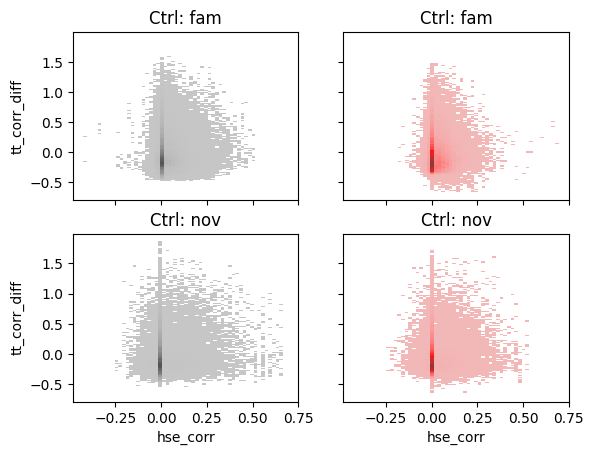

In [ ]:
# tt_corr vs hse_corr for active
fig,ax = plt.subplots(2,2, sharex=True, sharey=True)
sns.histplot(data=tmp_df.loc[(tmp_df['ttype']=='fam')*(tmp_df['condition']=='ctrl')],
             x='hse_corr',
             y='tt_corr_diff',
             color='black', ax=ax[0,0], binwidth=.02)
ax[0,0].set_title('Ctrl: fam')
_tmp_df = tmp_df.loc[(tmp_df['ttype']=='fam')*(tmp_df['condition']=='ctrl')]
r, p = sp.stats.spearmanr(_tmp_df['hse_corr'], _tmp_df['tt_corr_diff'], nan_policy='omit')
print(r,p)

sns.histplot(data=tmp_df.loc[(tmp_df['ttype']=='nov')*(tmp_df['condition']=='ctrl')],
             x='hse_corr',
             y='tt_corr_diff',
             color='black', ax=ax[1,0], binwidth=.02)
ax[1,0].set_title('Ctrl: nov')
_tmp_df = tmp_df.loc[(tmp_df['ttype']=='nov')*(tmp_df['condition']=='ctrl')]
r, p = sp.stats.spearmanr(_tmp_df['hse_corr'], _tmp_df['tt_corr_diff'], nan_policy='omit')
print(r,p)

sns.histplot(data=tmp_df.loc[(tmp_df['ttype']=='fam')*(tmp_df['condition']=='cre')],
             x='hse_corr',
             y='tt_corr_diff',
             color='red', ax=ax[0,1], binwidth=.02)
ax[0,1].set_title('Ctrl: fam')
_tmp_df = tmp_df.loc[(tmp_df['ttype']=='fam')*(tmp_df['condition']=='cre')]
r, p = sp.stats.spearmanr(_tmp_df['hse_corr'], _tmp_df['tt_corr_diff'], nan_policy='omit')
print(r,p)

sns.histplot(data=tmp_df.loc[(tmp_df['ttype']=='nov')*(tmp_df['condition']=='cre')],
             x='hse_corr',
             y='tt_corr_diff',
             color='red', ax=ax[1,1], binwidth=.02)
ax[1,1].set_title('Ctrl: nov')
_tmp_df = tmp_df.loc[(tmp_df['ttype']=='nov')*(tmp_df['condition']=='cre')]
r, p = sp.stats.spearmanr(_tmp_df['hse_corr'], _tmp_df['tt_corr_diff'], nan_policy='omit')
print(r,p)


In [ ]:

# df['ttype'] = df['ttype'].astype('category')
tmp_df['condition'] = tmp_df['condition'].astype('category')
tmp_df['hse_day'] = tmp_df['hse_day'].astype('category')
tmp_df['tt_day'] = tmp_df['tt_day'].astype('category')
tmp_df['mouse'] = tmp_df['mouse'].astype('category')
tmp_df['ttype'] = tmp_df['ttype'].astype('category')
tmp_df['rank_tt_corr_diff'] = tmp_df['tt_corr_diff'].rank()
tmp_df['rank_hse_corr'] = tmp_df['hse_corr_z'].rank()

_df = tmp_df.loc[tmp_df['ttype']=='nov']
mdl = smf.mixedlm("tt_corr_diff ~ condition*hse_corr_z + hse_day + tt_day",_df, groups=_df['mouse'])
res = mdl.fit()
res.summary()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
=======================================================================
Model:                 MixedLM     Dependent Variable:     tt_corr_diff
No. Observations:      137863      Method:                 REML        
No. Groups:            16          Scale:                  0.0967      
Min. group size:       678         Log-Likelihood:         -34626.5782 
Max. group size:       15650       Converged:              Yes         
Mean group size:       8616.4                                          
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                    -0.003    0.004 -0.830 0.407 -0.011  0.005
condition[T.ctrl]             0.003    0.003  1.048 0.295 -0.003  0.010
hse_day[T.1]                  0.002    0.002  0.691 0.489 -0.003  0.006
hse_day[T.2]                  0.006    0.003  2.163 0.031  0.001  0.011
hse_day[T.3]                  0.009    0.003  2.878 0.004  0.003  0.015
hse_day[T.4]                  0.007    0.004  1.908 0.056 -0.000  0.015
tt_day[T.2]                   0.000    0.004  0.022 0.982 -0.008  0.008
tt_day[T.3]                   0.002    0.004  0.406 0.684 -0.006  0.010
tt_day[T.4]                   0.000    0.004  0.014 0.989 -0.008  0.008
tt_day[T.5]                  -0.003    0.004 -0.813 0.416 -0.011  0.005
hse_corr_z                    0.065    0.019  3.365 0.001  0.027  0.104
condition[T.ctrl]:hse_corr_z  0.164    0.025  6.497 0.000  0.114  0.213
Group Var                     0.000    0.000                           
=======================================================================

"""

In [26]:
df_grouped = pd.concat([df_pos, df_neg], axis=0)
df_grouped['tt_day_diff'] = df_grouped['tt_day']-df_grouped['hse_day']

In [27]:
df_grouped.head()

,condition,hse_day,tt_day,ttype,mouse,hse_corr,tt_corr,across_day_corr,cell_argmax,hse_zero_mask,hse_corr_z,tt_corr_z,across_day_corr_z,positive,tt_corr_diff,tt_day_diff
0,cre,0,1,fam,4467975.1,0.073469,0.126423,0.574117,19.058394,0.0,0.073798,0.128715,0.777733,True,-0.034939,1
1,cre,0,1,fam,4467975.2,0.122131,0.195053,0.537680,17.333333,0.0,0.123524,0.206455,0.865175,True,-0.063052,1
2,cre,0,1,fam,4467975.3,0.058212,0.271284,0.599280,17.122222,0.0,0.058353,0.299659,0.930209,True,-0.043088,1
3,cre,0,1,fam,4467975.4,0.052975,0.263986,0.356273,15.333333,0.0,0.053096,0.297592,0.512596,True,-0.009675,1
4,cre,0,1,fam,4467975.5,0.063091,0.222717,0.485306,15.791411,0.0,0.063313,0.237987,0.685785,True,-0.032797,1


Text(0.5, 1.0, 'Cre: Nov')

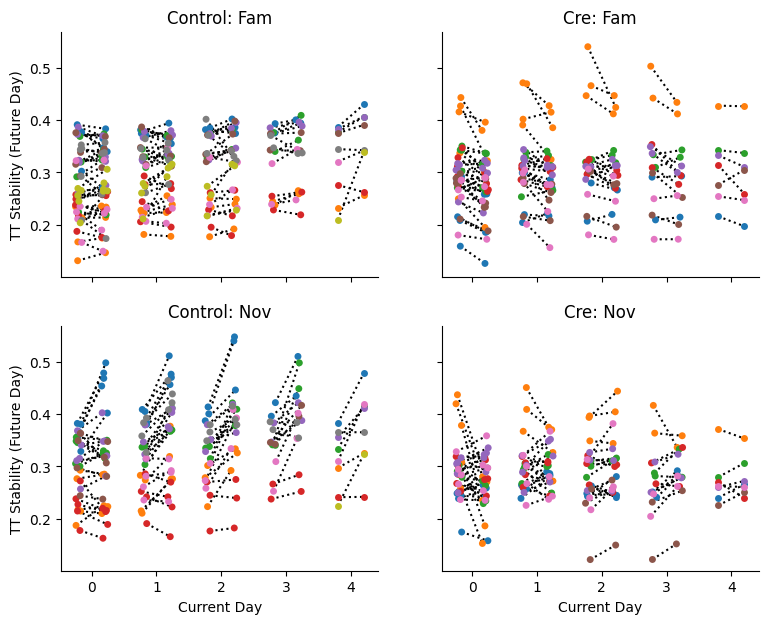

In [28]:
fig, ax = plt.subplots(2,2, figsize=(9,7), sharex=True, sharey=True)

for k, ttype in enumerate(['fam','nov']):
    old_ind = 0
    for i, mouse in enumerate(ctrl_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
            
        

        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,0])
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,0].collections[d].get_offsets(), ax[k,0].collections[d+1].get_offsets()):
                ax[k,0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
        


    old_ind = 0
    for i, mouse in enumerate(ko_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='cre') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,1])
        
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,1].collections[d].get_offsets(), ax[k,1].collections[d+1].get_offsets()):
                ax[k,1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Current Day')
    a.set_ylabel('TT Stability (Future Day)')
ax[0,0].set_title('Control: Fam')
ax[0,1].set_title('Cre: Fam')
ax[1,0].set_title('Control: Nov')
ax[1,1].set_title('Cre: Nov')


In [ ]:
import statsmodels.formula.api as smf
df_tmp = df_grouped.copy()
df_tmp['condition'] = df_tmp['condition'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['hse_day'] = df_tmp['hse_day'].astype('category')
df_tmp['tt_day'] = df_tmp['tt_day'].astype('category')
df_tmp['ttype'] = df_tmp['ttype'].astype('category')
df_tmp['positive'] = df_tmp['positive'].astype('category')
df_tmp['tt_corr_rank'] = df_tmp['tt_corr'].rank()
df_tmp['across_day_corr_rank'] = df_tmp['across_day_corr'].rank()




In [ ]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='nov']
model = smf.mixedlm("tt_corr_rank ~ positive * condition + hse_day + tt_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()



<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
==================================================================================
Model:                    MixedLM         Dependent Variable:         tt_corr_rank
No. Observations:         394             Method:                     REML        
No. Groups:               16              Scale:                      17926.0492  
Min. group size:          2               Log-Likelihood:             -2463.3110  
Max. group size:          30              Converged:                  Yes         
Mean group size:          24.6                                                    
----------------------------------------------------------------------------------
                                     Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------------------
Intercept                            154.870   78.767  1.966 0.049   0.490 309.250
positive[T.True]                      -0.875   19.325 -0.045 0.964 -38.751  37.001
condition[T.ctrl]                    123.787   99.315  1.246 0.213 -70.867 318.441
hse_day[T.1]                          47.981   19.494  2.461 0.014   9.774  86.189
hse_day[T.2]                          55.350   21.413  2.585 0.010  13.382  97.318
hse_day[T.3]                          73.996   24.469  3.024 0.002  26.037 121.955
hse_day[T.4]                          72.904   31.644  2.304 0.021  10.884 134.925
tt_day[T.2]                           80.241   34.678  2.314 0.021  12.274 148.208
tt_day[T.3]                          211.225   33.418  6.321 0.000 145.728 276.723
tt_day[T.4]                          177.096   32.960  5.373 0.000 112.495 241.697
tt_day[T.5]                          129.521   32.960  3.930 0.000  64.920 194.122
positive[T.True]:condition[T.ctrl]   101.627   26.989  3.765 0.000  48.729 154.526
Group Var                          37021.835  109.995                             
==================================================================================

"""

Shapiro-Wilk: W=0.991, p=0.0125
D'Agostino: χ²=6.814, p=0.0331


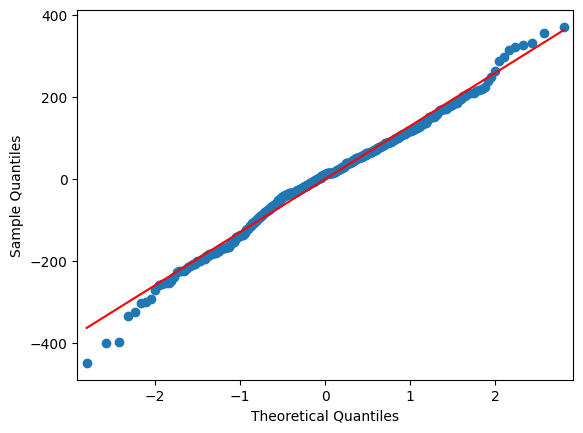

In [ ]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [ ]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='fam']
model = smf.mixedlm("tt_corr ~ positive * condition + hse_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                     MixedLM        Dependent Variable:        tt_corr 
No. Observations:          476            Method:                    REML    
No. Groups:                16             Scale:                     0.0015  
Min. group size:           26             Log-Likelihood:            813.6420
Max. group size:           30             Converged:                 Yes     
Mean group size:           29.8                                              
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.289    0.022 13.156 0.000  0.246  0.332
positive[T.True]                   -0.021    0.005 -4.012 0.000 -0.032 -0.011
condition[T.ctrl]                  -0.007    0.029 -0.234 0.815 -0.064  0.050
hse_day[T.1]                        0.021    0.005  4.515 0.000  0.012  0.030
hse_day[T.2]                        0.027    0.005  5.432 0.000  0.017  0.037
hse_day[T.3]                        0.033    0.006  5.611 0.000  0.021  0.044
hse_day[T.4]                        0.041    0.007  5.475 0.000  0.026  0.055
positive[T.True]:condition[T.ctrl]  0.027    0.007  3.816 0.000  0.013  0.041
Group Var                           0.003    0.033                           
=============================================================================

"""

In [ ]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='fam']
model = smf.mixedlm("across_day_corr_rank ~ positive * condition + hse_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                 MixedLM      Dependent Variable:      across_day_corr_rank
No. Observations:      476          Method:                  REML                
No. Groups:            16           Scale:                   29160.7748          
Min. group size:       26           Log-Likelihood:          -3102.6894          
Max. group size:       30           Converged:               Yes                 
Mean group size:       29.8                                                      
---------------------------------------------------------------------------------
                                    Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                           320.943   39.245  8.178 0.000 244.024 397.861
positive[T.True]                    -40.295   23.568 -1.710 0.087 -86.487   5.897
condition[T.ctrl]                     1.960   50.245  0.039 0.969 -96.518 100.437
hse_day[T.1]                        201.377   20.250  9.944 0.000 161.687 241.066
hse_day[T.2]                        321.390   22.046 14.578 0.000 278.181 364.598
hse_day[T.3]                        407.033   25.931 15.697 0.000 356.209 457.857
hse_day[T.4]                        466.119   33.069 14.096 0.000 401.306 530.932
positive[T.True]:condition[T.ctrl]   39.498   31.527  1.253 0.210 -22.294 101.290
Group Var                          7982.204   20.133                             
=================================================================================

"""

In [ ]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='nov']
model = smf.mixedlm("across_day_corr_rank ~ positive * condition + hse_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                 MixedLM      Dependent Variable:      across_day_corr_rank
No. Observations:      414          Method:                  REML                
No. Groups:            16           Scale:                   21168.5146          
Min. group size:       2            Log-Likelihood:          -2631.0025          
Max. group size:       30           Converged:               Yes                 
Mean group size:       25.9                                                      
---------------------------------------------------------------------------------
                                    Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                            89.229   38.853  2.297 0.022  13.078 165.380
positive[T.True]                      7.177   21.000  0.342 0.733 -33.983  48.337
condition[T.ctrl]                    79.584   50.274  1.583 0.113 -18.951 178.120
hse_day[T.1]                        203.535   18.896 10.771 0.000 166.500 240.570
hse_day[T.2]                        310.231   20.821 14.900 0.000 269.423 351.040
hse_day[T.3]                        433.052   23.634 18.323 0.000 386.731 479.374
hse_day[T.4]                        487.466   29.259 16.660 0.000 430.119 544.813
positive[T.True]:condition[T.ctrl]   55.156   28.678  1.923 0.054  -1.052 111.364
Group Var                          8070.822   23.751                             
=================================================================================

"""

In [ ]:
# permutation test

Text(0.5, 1.0, 'Cre: Nov')

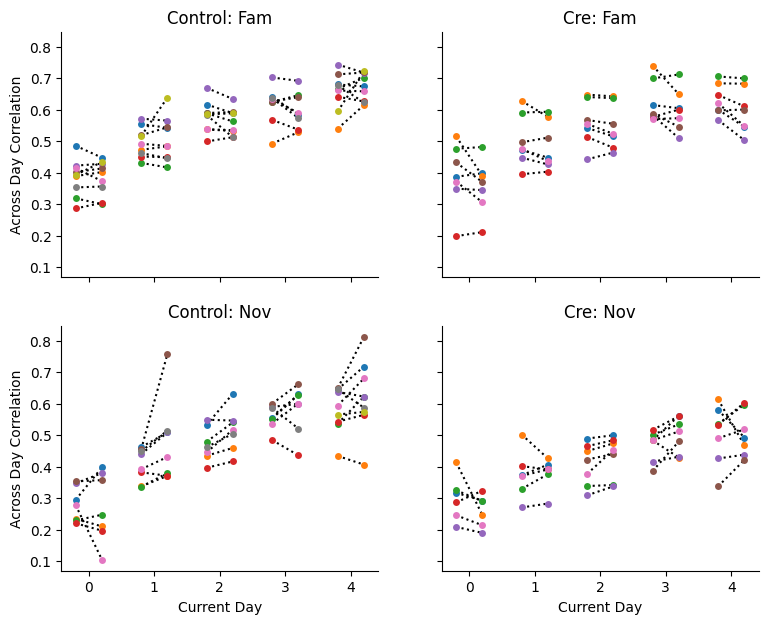

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(9,7), sharex=True, sharey=True)

for k, ttype in enumerate(['fam','nov']):
    old_ind = 0
    for i, mouse in enumerate(ctrl_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
            
        

        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='across_day_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,0])
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,0].collections[d].get_offsets(), ax[k,0].collections[d+1].get_offsets()):
                ax[k,0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
        


    old_ind = 0
    for i, mouse in enumerate(ko_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='cre') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='across_day_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,1])
        
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,1].collections[d].get_offsets(), ax[k,1].collections[d+1].get_offsets()):
                ax[k,1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Current Day')
    a.set_ylabel('Across Day Correlation')
ax[0,0].set_title('Control: Fam')
ax[0,1].set_title('Cre: Fam')
ax[1,0].set_title('Control: Nov')
ax[1,1].set_title('Cre: Nov')
